In [10]:
import os
from importlib import reload
import sys
sys.path.insert(
    0, r'C:\Users\richa\GitHub\py_neuromodulation\pyneuromodulation')

from matplotlib import pyplot as plt
import numpy as np
import pandas as pd

from pybv import write_brainvision
import mne
import mne_bids

import start_BIDS
import define_M1
import nm_reader as NM_reader


def get_all_files(path, suffix, get_bids=False, prefix=None, bids_root=None,
                  verbose=False, extension=None):
    """Return all files in all (sub-)directories of path with given suffixes and prefixes (case-insensitive).

    Args:
        path (string)
        suffix (iterable): e.g. ["vhdr", "edf"] or ".json"
        get_bids (boolean): True if BIDS_Path type should be returned instead of string. Default: False
        bids_root (string/path): Path of BIDS root folder. Only required if get_bids=True.
        prefix (iterable): e.g. ["SelfpacedRota", "ButtonPress] (optional)

    Returns:
        filepaths (list of strings or list of BIDS_Path)
    """

    if isinstance(suffix, str):
        suffix = [suffix]
    if isinstance(prefix, str):
        prefix = [prefix]

    filepaths = []
    for root, dirs, files in os.walk(path):
        for file in files:
            for suff in suffix:
                if file.endswith(suff.lower()):
                    if not prefix:
                        filepaths.append(os.path.join(root, file))
                    else:
                        for pref in prefix:
                            if pref.lower() in file.lower():
                                filepaths.append(os.path.join(root, file))

    bids_paths = filepaths
    if get_bids:
        if not bids_root:
            print(
                "Warning: No root folder given. Please pass bids_root parameter to create a complete BIDS_Path object.")
        bids_paths = []
        for filepath in filepaths:
            entities = mne_bids.get_entities_from_fname(filepath)
            try:
                bids_path = mne_bids.BIDSPath(subject=entities["subject"],
                                              session=entities["session"],
                                              task=entities["task"],
                                              run=entities["run"],
                                              acquisition=entities[
                                                  "acquisition"],
                                              suffix=entities["suffix"],
                                              extension=extension,
                                              root=bids_root)
            except ValueError as err:
                print(
                    f"ValueError while creating BIDS_Path object for file {filepath}: {err}")
            else:
                bids_paths.append(bids_path)

    if verbose:
        if not bids_paths:
            print("No corresponding files found.")
        else:
            print('Corresponding files found:')
            for idx, file in enumerate(bids_paths):
                print(idx, ':', os.path.basename(file))

    return bids_paths

In [11]:
out_root = r'C:\Users\richa\OneDrive - Charité - Universitätsmedizin Berlin\Beijing_ECOG_LFP_derivatives\pipeline-MotOnsetPred_2021-04-26'
deriv_root = os.path.join(out_root, 'derivatives', 'feat_no_clip')

files = get_all_files(
    path=deriv_root,
    suffix='.csv',
    get_bids=False,
    prefix="features",
    bids_root=deriv_root,
    verbose=True,
    extension=None)

Corresponding files found:
0 : sub-FOG006_ses-EphysMedOn_task-ButtonPress_acq-StimOff_run-01_ieeg_FEATURES.csv
1 : sub-FOG008_ses-EphysMedOn_task-ButtonPress_acq-StimOff_run-01_ieeg_FEATURES.csv
2 : sub-FOG010_ses-EphysMedOff_task-ButtonPress_acq-StimOff_run-01_ieeg_FEATURES.csv
3 : sub-FOG013_ses-EphysMedOff_task-ButtonPress_acq-StimOff_run-01_ieeg_FEATURES.csv
4 : sub-FOGC001_ses-EphysMedOff_task-ButtonPress_acq-StimOff_run-01_ieeg_FEATURES.csv


In [34]:
def run_example_read_features(feature_file, ch_name, label):
    """"""
    settings = nm_reader.read_settings(feature_file)

    # read run_analysis
    run_analyzer = nm_reader.read_run_analyzer()

    # optionally read ML estimations
    ML_est = nm_reader.read_ML_estimations()

    df_ = nm_reader.read_M1(feature_file)
    features_ = nm_reader.read_features(feature_file)

    channels = np.array(settings['ch_names'])
    label_name = [ch for ch in channels if label in ch]
    dat_label = nm_reader.read_label(label_name[0])
    nm_reader.label = stats.zscore(dat_label)

    # Fist case: filter for bandpass activity features only
    dat_ch = nm_reader.read_channel_data(ch_name, read_bp_activity_only=True)

    # estimating epochs, with shape (epochs,samples,channels,features)
    X_epoch, y_epoch = nm_reader.get_epochs_ch(
        epoch_len=6, sfreq=settings["sampling_rate_features"], threshold=0.)
    print("Plotting feature covariance matrix.")
    nm_reader.plot_corr_matrix(feature_file, feature_str_add="bandpass")
    print("Plotting feature target averaged.")
    nm_reader.plot_epochs_avg(feature_file, feature_str_add="bandpass")

In [13]:
def get_feat_array(data, events, sfreq, movement_begin, movement_end, dist_onset, dist_end,
                   exclude=True):
    """
    begin: time point start of label 'Motor Intention': e.g. -1.25 for 1.25 secs before motor onset
    end: time point end of label 'Motor Intention': e.g. -0.25 for 0.25 secs before motor onset. 
         Enter 'MovementEnd' if label 'Motor Intention' ends at end of movement
    """
    # Label: 'No Motor Intention' between 3 secs after movement end and 2 secs (ind_a) before movement begin
    ind_a = int(dist_onset*sfreq)
    ind_b = int(dist_end*sfreq)
    
    rest_begin, rest_end = int(-3 * sfreq), int(-2 * sfreq)
    mov_begin = int(movement_begin * sfreq)
    mov_end = int(movement_end * sfreq)
    mov_diff = abs(mov_begin - mov_end)
    
    X = list()
    y = list()
    events_used = list()
    group_list = list()
    
    for i, index in enumerate(np.arange(0, len(events), 2)):
        if i == 0:
            rest_diff = abs(rest_begin - rest_end)
            y.extend((np.zeros(rest_diff), np.ones(mov_diff)))
            X.extend((data[events[index] + rest_begin:events[index] + rest_end],
                     data[events[index] + mov_begin:events[index] + mov_end]))
            events_used.append(index)
            group_list.append(np.full((rest_diff + mov_diff), i))
        else:
            rest_diff = (events[index] - ind_a) - (events[index-1] + ind_b)
            if rest_diff < int(1*sfreq):
                if exclude is True:
                    pass
                else:
                    y.append(np.ones(mov_diff))
                    X.extend((data[events[index] + mov_begin:events[index] + mov_end]))
                    events_used.append(index)
                    group_list.append(np.full((mov_diff), i))
            else:
                rest_diff = abs(rest_begin - rest_end)
                y.extend((np.zeros(rest_diff), np.ones(mov_diff)))
                X.extend((data[events[index] + rest_begin:events[index] + rest_end],
                         data[events[index] + mov_begin:events[index] + mov_end]))
                #X.extend((data[events[index-1] + ind_b:events[index] - ind_a], 
                 #         data[events[index] + mov_begin:events[index] + mov_end]))
                events_used.append(index)
                group_list.append(np.full((rest_diff + mov_diff), i))
    print('EVENTS USED:', len(events_used))
    return np.concatenate(X, axis=0).squeeze(), np.concatenate(y), np.array(events_used), np.concatenate(group_list)

In [17]:
from operator import itemgetter

import seaborn as sb

from sklearn.model_selection import (cross_validate, GroupKFold, GroupShuffleSplit)
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

def max_val(l, i):
    """Return maximum value and index from list of lists."""
    return max(enumerate(map(itemgetter(i), l)),key=itemgetter(1))

def classify_lda(
    features_, events_, channel, movement_begin, 
    movement_end, dist_onset, dist_end, verbose):
    """"""
    cols = [col for col in features_.columns if channel in col]
    feat_picks_ = features_[cols]
    dat_ = feat_picks_.values
    X, y, events_used_, groups = get_feat_array(
        dat_, events_, sfreq=10, 
        movement_begin=movement_begin, movement_end=movement_end,
        dist_onset=dist_onset, dist_end=dist_end,
        exclude=True)
    clf = LinearDiscriminantAnalysis(solver='lsqr', shrinkage='auto')
    cv = GroupShuffleSplit(n_splits = 5)
    scores = cross_validate(clf, X, y, cv=cv, groups=groups, 
                            scoring=['average_precision', 'accuracy'])
    AP = np.mean(scores['test_average_precision'])
    accuracy = np.mean(scores['test_accuracy'])
    if verbose:
        print(ch, ':', 'CV-AP: ', AP, 'CV-Accuracy: ', accuracy)
    return AP, accuracy


# Calculate performance

In [18]:
nm_reader = NM_reader.NM_Reader(deriv_root)
feature_list = nm_reader.get_feature_list()
print(*feature_list, sep='\n')

sub-FOG006_ses-EphysMedOn_task-ButtonPress_acq-StimOff_run-01_ieeg
sub-FOG008_ses-EphysMedOn_task-ButtonPress_acq-StimOff_run-01_ieeg
sub-FOG010_ses-EphysMedOff_task-ButtonPress_acq-StimOff_run-01_ieeg
sub-FOG013_ses-EphysMedOff_task-ButtonPress_acq-StimOff_run-01_ieeg
sub-FOGC001_ses-EphysMedOff_task-ButtonPress_acq-StimOff_run-01_ieeg


In [19]:
### MOTOR ONSET ###
mov_begin = -1.
mov_end = 0.
###################
contralateral = [
    'sub-FOG006_ses-EphysMedOn_task-ButtonPress_acq-StimOff_run-01_ieeg',
    'sub-FOG008_ses-EphysMedOn_task-ButtonPress_acq-StimOff_run-01_ieeg',
    'sub-FOG010_ses-EphysMedOff_task-ButtonPress_acq-StimOff_run-01_ieeg',
    'sub-FOG013_ses-EphysMedOff_task-ButtonPress_acq-StimOff_run-01_ieeg',
    'sub-FOGC001_ses-EphysMedOff_task-ButtonPress_acq-StimOff_run-01_ieeg'
]
runs = {"Contralateral": contralateral}
for name, run in runs.items():
    run_list = list() 
    for feature_file in run:
        print(feature_file)
        features_ = nm_reader.read_features(feature_file)
        settings_ = nm_reader.read_settings(feature_file)
        channels = np.array(settings_['ch_names'])[settings_['feature_idx']]
        label_ = nm_reader.read_label('EMG_squared')
        feat_picks = ['bandpass_activity_theta', 'bandpass_activity_alpha', 
                   'bandpass_activity_low beta', 'bandpass_activity_high beta', 
                   'bandpass_activity_low gamma', 'bandpass_activity_high gamma']
        ecog_picks = ['ECOG']
        lfp_picks = ['LFP']
        column_picks = [col for col in features_.columns if any([pick in col for pick in feat_picks])]
        features_ = features_[column_picks]
        features_diff_ = features_.diff(axis=0).fillna(0.)
        features_diff_ = features_diff_.add_suffix('_diff')
        features_ = pd.concat((features_, features_diff_), axis=1)
        dat_label_ = label_.values
        diff_ = np.zeros_like(dat_label_, dtype=int)
        diff_[1:] = np.diff(dat_label_)
        events_ = np.nonzero(diff_)[0]
        ecog_chs = [ch for ch in channels if 'ECOG' in ch]
        lfp_chs = [ch for ch in channels if 'LFP' in ch]
        chs = ecog_chs + lfp_chs
        curr_list = list()
        ecog_list = list()
        dist_onset_ = 2.
        dist_end_ = 0. if feature_file == 'sub-FOG006_ses-EphysMedOn_task-ButtonPress_acq-StimOff_run-01_ieeg' else 2.
        for ch in ecog_chs:
            AP, accuracy = classify_lda(
                features_, events_, ch, mov_begin, mov_end, 
                dist_onset_, dist_end_, True)
            ecog_list.append([AP, accuracy])
            curr_list.append([AP, accuracy]) 
        lfp_list = list()    
        for ch in lfp_chs:
            AP, accuracy = classify_lda(
                features_, events_, ch, mov_begin, mov_end, 
                dist_onset_, dist_end_, True)
            lfp_list.append([AP, accuracy])
            curr_list.append([AP, accuracy])
        # Now select best performance by best accuracy: "1"
        lfp_max = max_val(lfp_list, 1)[0]
        ecog_max = max_val(ecog_list, 1)[0]
        run_list.append([lfp_chs[lfp_max]] + lfp_list[lfp_max]
                        + [ecog_chs[ecog_max]] + ecog_list[ecog_max])
        curr_df = pd.DataFrame(data=curr_list, index=chs, 
                               columns=['average_precision', 'accuracy'])
        out_file = os.path.join(deriv_root, feature_file, 
                                feature_file+'mot_onset_accuracy_AP.tsv')
        curr_df.to_csv(out_file, sep='\t')
    run_df = pd.DataFrame(
        data=run_list, index=run, 
        columns=['LFP_best_ch', 'LFP_best_average_precision', 'LFP_best_accuracy', 
                 'ECOG_best_ch', 'ECOG_best_average_precision', 'ECOG_best_accuracy'])
    out_file_run = os.path.join(deriv_root, name+'_mot_onset_group.tsv')
    run_df.to_csv(out_file_run, sep='\t')

sub-FOG006_ses-EphysMedOn_task-ButtonPress_acq-StimOff_run-01_ieeg
EVENTS USED: 126
ECOG_R_1_SM_HH-avgref : CV-AP:  0.6887083816545351 CV-Accuracy:  0.691923076923077
EVENTS USED: 126
ECOG_R_2_SM_HH-avgref : CV-AP:  0.7064300606637192 CV-Accuracy:  0.6788461538461539
EVENTS USED: 126
ECOG_R_3_SM_HH-avgref : CV-AP:  0.691744244222337 CV-Accuracy:  0.6557692307692309
EVENTS USED: 126
ECOG_R_4_SM_HH-avgref : CV-AP:  0.8178988578479714 CV-Accuracy:  0.7434615384615385
EVENTS USED: 126
ECOG_R_5_SM_HH-avgref : CV-AP:  0.8233845198702012 CV-Accuracy:  0.7707692307692308
EVENTS USED: 126
ECOG_R_6_SM_HH-avgref : CV-AP:  0.7738699759835092 CV-Accuracy:  0.7303846153846154
EVENTS USED: 126
ECOG_R_7_SM_HH-avgref : CV-AP:  0.6181570889023463 CV-Accuracy:  0.5653846153846154
EVENTS USED: 126
ECOG_R_8_SM_HH-avgref : CV-AP:  0.612716533750844 CV-Accuracy:  0.5657692307692308
EVENTS USED: 126
LFP_L_4_1_STN_PI : CV-AP:  0.5524247662349071 CV-Accuracy:  0.5419230769230768
EVENTS USED: 126
LFP_L_2_1_STN_P

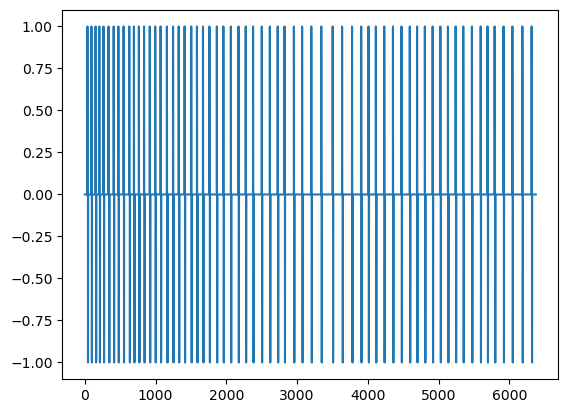

In [39]:
plt.plot(diff_)

In [22]:
### MOVEMENT ###
mov_begin = 0.
mov_end = 1.
###################
contralateral = [
    'sub-FOG006_ses-EphysMedOn_task-ButtonPress_acq-StimOff_run-01_ieeg',
    'sub-FOG008_ses-EphysMedOn_task-ButtonPress_acq-StimOff_run-01_ieeg',
    'sub-FOG010_ses-EphysMedOff_task-ButtonPress_acq-StimOff_run-01_ieeg',
    'sub-FOG013_ses-EphysMedOff_task-ButtonPress_acq-StimOff_run-01_ieeg',
    'sub-FOGC001_ses-EphysMedOff_task-ButtonPress_acq-StimOff_run-01_ieeg'
]

runs = {"Contralateral": contralateral}
for name, run in runs.items():
    i = 0
    run_list = list() 
    for feature_file in run:
        print(feature_file)
        features_ = nm_reader.read_features(feature_file)
        settings_ = nm_reader.read_settings(feature_file)
        channels = np.array(settings_['ch_names'])[settings_['feature_idx']]
        label_ = nm_reader.read_label('EMG_squared')
        feat_picks = ['bandpass_activity_theta', 'bandpass_activity_alpha', 
                   'bandpass_activity_low beta', 'bandpass_activity_high beta', 
                   'bandpass_activity_low gamma', 'bandpass_activity_high gamma']
        ecog_picks = ['ECOG']
        lfp_picks = ['LFP']
        column_picks = [col for col in features_.columns if any([pick in col for pick in feat_picks])]
        features_ = features_[column_picks]
        features_diff_ = features_.diff(axis=0).fillna(0.)
        features_diff_ = features_diff_.add_suffix('_diff')
        features_ = pd.concat((features_, features_diff_), axis=1)
        dat_label_ = label_.values
        diff_ = np.zeros_like(dat_label_, dtype=int)
        diff_[1:] = np.diff(dat_label_)
        events_ = np.nonzero(diff_)[0]
        ecog_chs = [ch for ch in channels if 'ECOG' in ch]
        lfp_chs = [ch for ch in channels if 'LFP' in ch]
        chs = ecog_chs + lfp_chs
        curr_list = list()
        ecog_list = list()
        dist_onset_ = 2.
        dist_end_ = 0. if feature_file == 'sub-FOG006_ses-EphysMedOn_task-ButtonPress_acq-StimOff_run-01_ieeg' else 2.
        for ch in ecog_chs:
            AP, accuracy = classify_lda(
                features_, events_, ch, mov_begin, mov_end, 
                dist_onset_, dist_end_, True)
            ecog_list.append([AP, accuracy])
            curr_list.append([AP, accuracy]) 
        lfp_list = list()    
        for ch in lfp_chs:
            AP, accuracy = classify_lda(
                features_, events_, ch, mov_begin, mov_end, 
                dist_onset_, dist_end_, True)
            lfp_list.append([AP, accuracy])
            curr_list.append([AP, accuracy])
        # Now select best performance by best accuracy: "1"
        lfp_max = max_val(lfp_list, 1)[0]
        ecog_max = max_val(ecog_list, 1)[0]
        run_list.append([lfp_chs[lfp_max]] + lfp_list[lfp_max]
                        + [ecog_chs[ecog_max]] + ecog_list[ecog_max])
        curr_df = pd.DataFrame(data=curr_list, index=chs, 
                               columns=['average_precision', 'accuracy'])
        out_file = os.path.join(deriv_root, feature_file, 
                                feature_file+'mot_onset_accuracy_AP.tsv')
        curr_df.to_csv(out_file, sep='\t')
    run_df = pd.DataFrame(
        data=run_list, index=run, 
        columns=['LFP_best_ch', 'LFP_best_average_precision', 'LFP_best_accuracy', 
                 'ECOG_best_ch', 'ECOG_best_average_precision', 'ECOG_best_accuracy'])
    out_file_run = os.path.join(deriv_root, name+'_movement_group.tsv')
    run_df.to_csv(out_file_run, sep='\t')

sub-FOG006_ses-EphysMedOn_task-ButtonPress_acq-StimOff_run-01_ieeg
EVENTS USED: 126
ECOG_R_1_SM_HH-avgref : CV-AP:  0.764119646251736 CV-Accuracy:  0.7307692307692307
EVENTS USED: 126
ECOG_R_2_SM_HH-avgref : CV-AP:  0.7692166700023432 CV-Accuracy:  0.7230769230769231
EVENTS USED: 126
ECOG_R_3_SM_HH-avgref : CV-AP:  0.8307203926362506 CV-Accuracy:  0.7534615384615384
EVENTS USED: 126
ECOG_R_4_SM_HH-avgref : CV-AP:  0.9175036621157824 CV-Accuracy:  0.8249999999999998
EVENTS USED: 126
ECOG_R_5_SM_HH-avgref : CV-AP:  0.8232801111003804 CV-Accuracy:  0.7511538461538462
EVENTS USED: 126
ECOG_R_6_SM_HH-avgref : CV-AP:  0.8094856792058703 CV-Accuracy:  0.7407692307692308
EVENTS USED: 126
ECOG_R_7_SM_HH-avgref : CV-AP:  0.5745135887060858 CV-Accuracy:  0.5776923076923077
EVENTS USED: 126
ECOG_R_8_SM_HH-avgref : CV-AP:  0.5996025746919486 CV-Accuracy:  0.5726923076923077
EVENTS USED: 126
LFP_L_4_1_STN_PI : CV-AP:  0.5734857231791579 CV-Accuracy:  0.5542307692307693
EVENTS USED: 126
LFP_L_2_1_STN

In [23]:
group_files = get_all_files(
    path=deriv_root,
    suffix='.tsv',
    get_bids=False,
    prefix="group",
    bids_root=deriv_root,
    verbose=True,
    extension=None)

Corresponding files found:
0 : Contralateral_mot_onset_group.tsv
1 : Contralateral_movement_group.tsv


# Motor Onset

In [24]:
df_list = list()
for file in group_files[0:1]:
    df = pd.read_csv(file, sep='\t', index_col=[0], header=[0])
    for col in df.columns:
        if "accuracy" in col:
            new_df = pd.DataFrame(columns = ['Accuracy', 'Channel', 'Hemisphere', 'Recording'], index=df.index)
            series = pd.Series(df[col], index=df.index)
            new_df['Accuracy'] = series
            new_df['Recording'] = series.index
            if "LFP" in col:
                best_ch = df.loc[:,"LFP_best_ch"].str.slice(stop=-7)
            elif "ECOG" in col:
                best_ch = df.loc[:,"ECOG_best_ch"].str.slice(stop=-13)
            new_df['Best_Channel'] = best_ch
            new_df['Channel'] = "Best LFP" if "LFP" in col else "Best ECOG"
            new_df['Hemisphere'] = "Contralateral" if "Contralateral" in file else "Ipsilateral"
            df_list.append(new_df)
final_df = pd.concat(df_list)

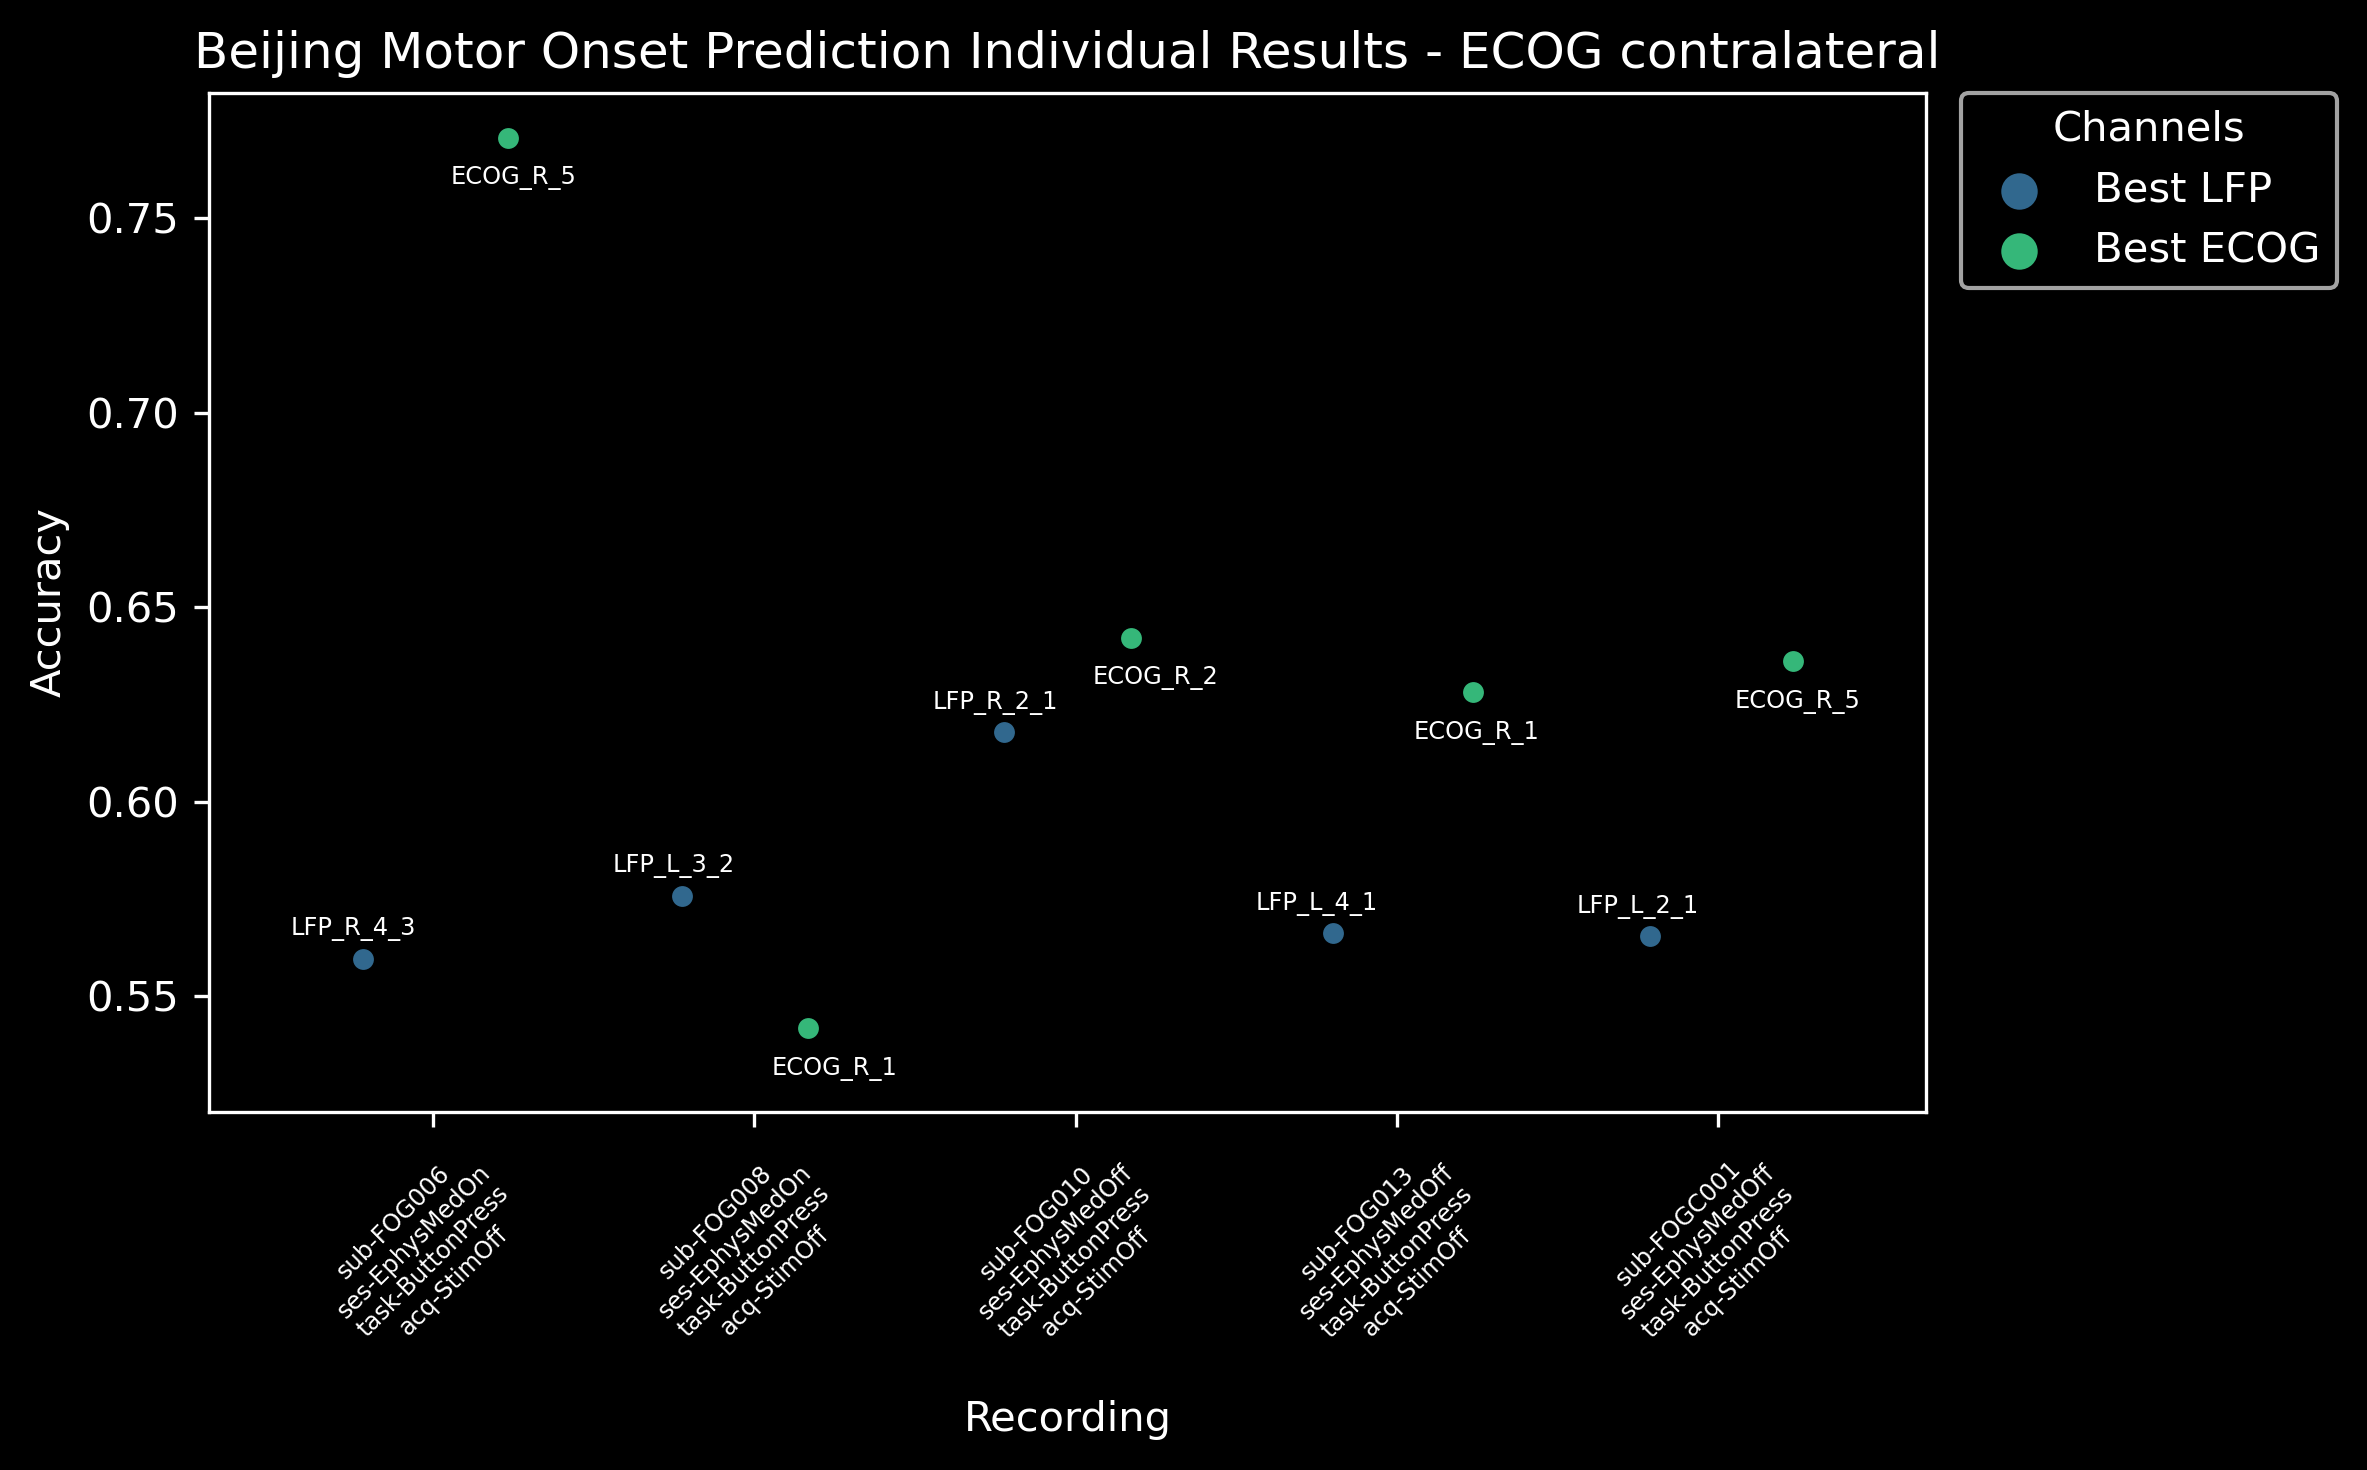

In [25]:
outpath = os.path.join(deriv_root, 'beijing_mot_onset_class_sLDA_no_feat_clip_indiv_scores_contralat_dark.png')
df = final_df
plt.style.use('dark_background')
alpha_box = 0.4
plt.figure(figsize=(8,5), dpi=300)

ax = sb.stripplot(x="Recording", y="Accuracy", hue="Channel", 
                  data=df, palette="viridis", dodge=True, s=5)
tick_label = ax.get_xticklabels()
tick_dict = dict()
for x in ax.get_xticks():
    tick_dict[tick_label[x].get_text()] = x
for line, name in enumerate(df.index):
    if "LFP" in df["Best_Channel"][line]:
        x_offset = -0.25
        y_offset = +0.006
        align = 'center'
    elif "ECOG" in df["Best_Channel"][line]:
        x_offset = +0.25
        y_offset = -0.012
        align = 'center'
    ax.text(tick_dict[name]+x_offset, df.Accuracy[line]+y_offset, 
             df.Best_Channel[line], horizontalalignment=align, 
             size='xx-small', color='white')

plt.xticks(rotation=45)
xlabels = [item.get_text() for item in ax.get_xticklabels()]
new_xlabels = [xtick.replace('_','\n')[:-11] for xtick in xlabels]
ax.set_xticklabels(new_xlabels, fontdict={'fontsize':'xx-small'})
ax.set_xlim(left=ax.get_xlim()[0]-0.2, right=ax.get_xlim()[1]+0.15)
ax.set_ylim(bottom=ax.get_ylim()[0]-0.01)
handles, labels = ax.get_legend_handles_labels()
l = plt.legend(handles[:len(handles)], labels[:len(labels)], 
               bbox_to_anchor=(1.02, 1), loc=2, borderaxespad=0., title='Channels')
plt.title("Beijing Motor Onset Prediction Individual Results - ECOG contralateral")
plt.tight_layout()
plt.savefig(outpath)

# Movement

In [26]:
df_list = list()
for file in group_files[1:]:
    df = pd.read_csv(file, sep='\t', index_col=[0], header=[0])
    for col in df.columns:
        if "accuracy" in col:
            new_df = pd.DataFrame(columns = ['Accuracy', 'Channel', 'Hemisphere', 'Recording'], index=df.index)
            series = pd.Series(df[col], index=df.index)
            new_df['Accuracy'] = series
            new_df['Recording'] = series.index
            if "LFP" in col:
                best_ch = df.loc[:,"LFP_best_ch"].str.slice(stop=-7)
            elif "ECOG" in col:
                best_ch = df.loc[:,"ECOG_best_ch"].str.slice(stop=-13)
            new_df['Best_Channel'] = best_ch
            new_df['Channel'] = "Best LFP" if "LFP" in col else "Best ECOG"
            new_df['Hemisphere'] = "Contralateral" if "Contralateral" in file else "Ipsilateral"
            df_list.append(new_df)
final_df = pd.concat(df_list)

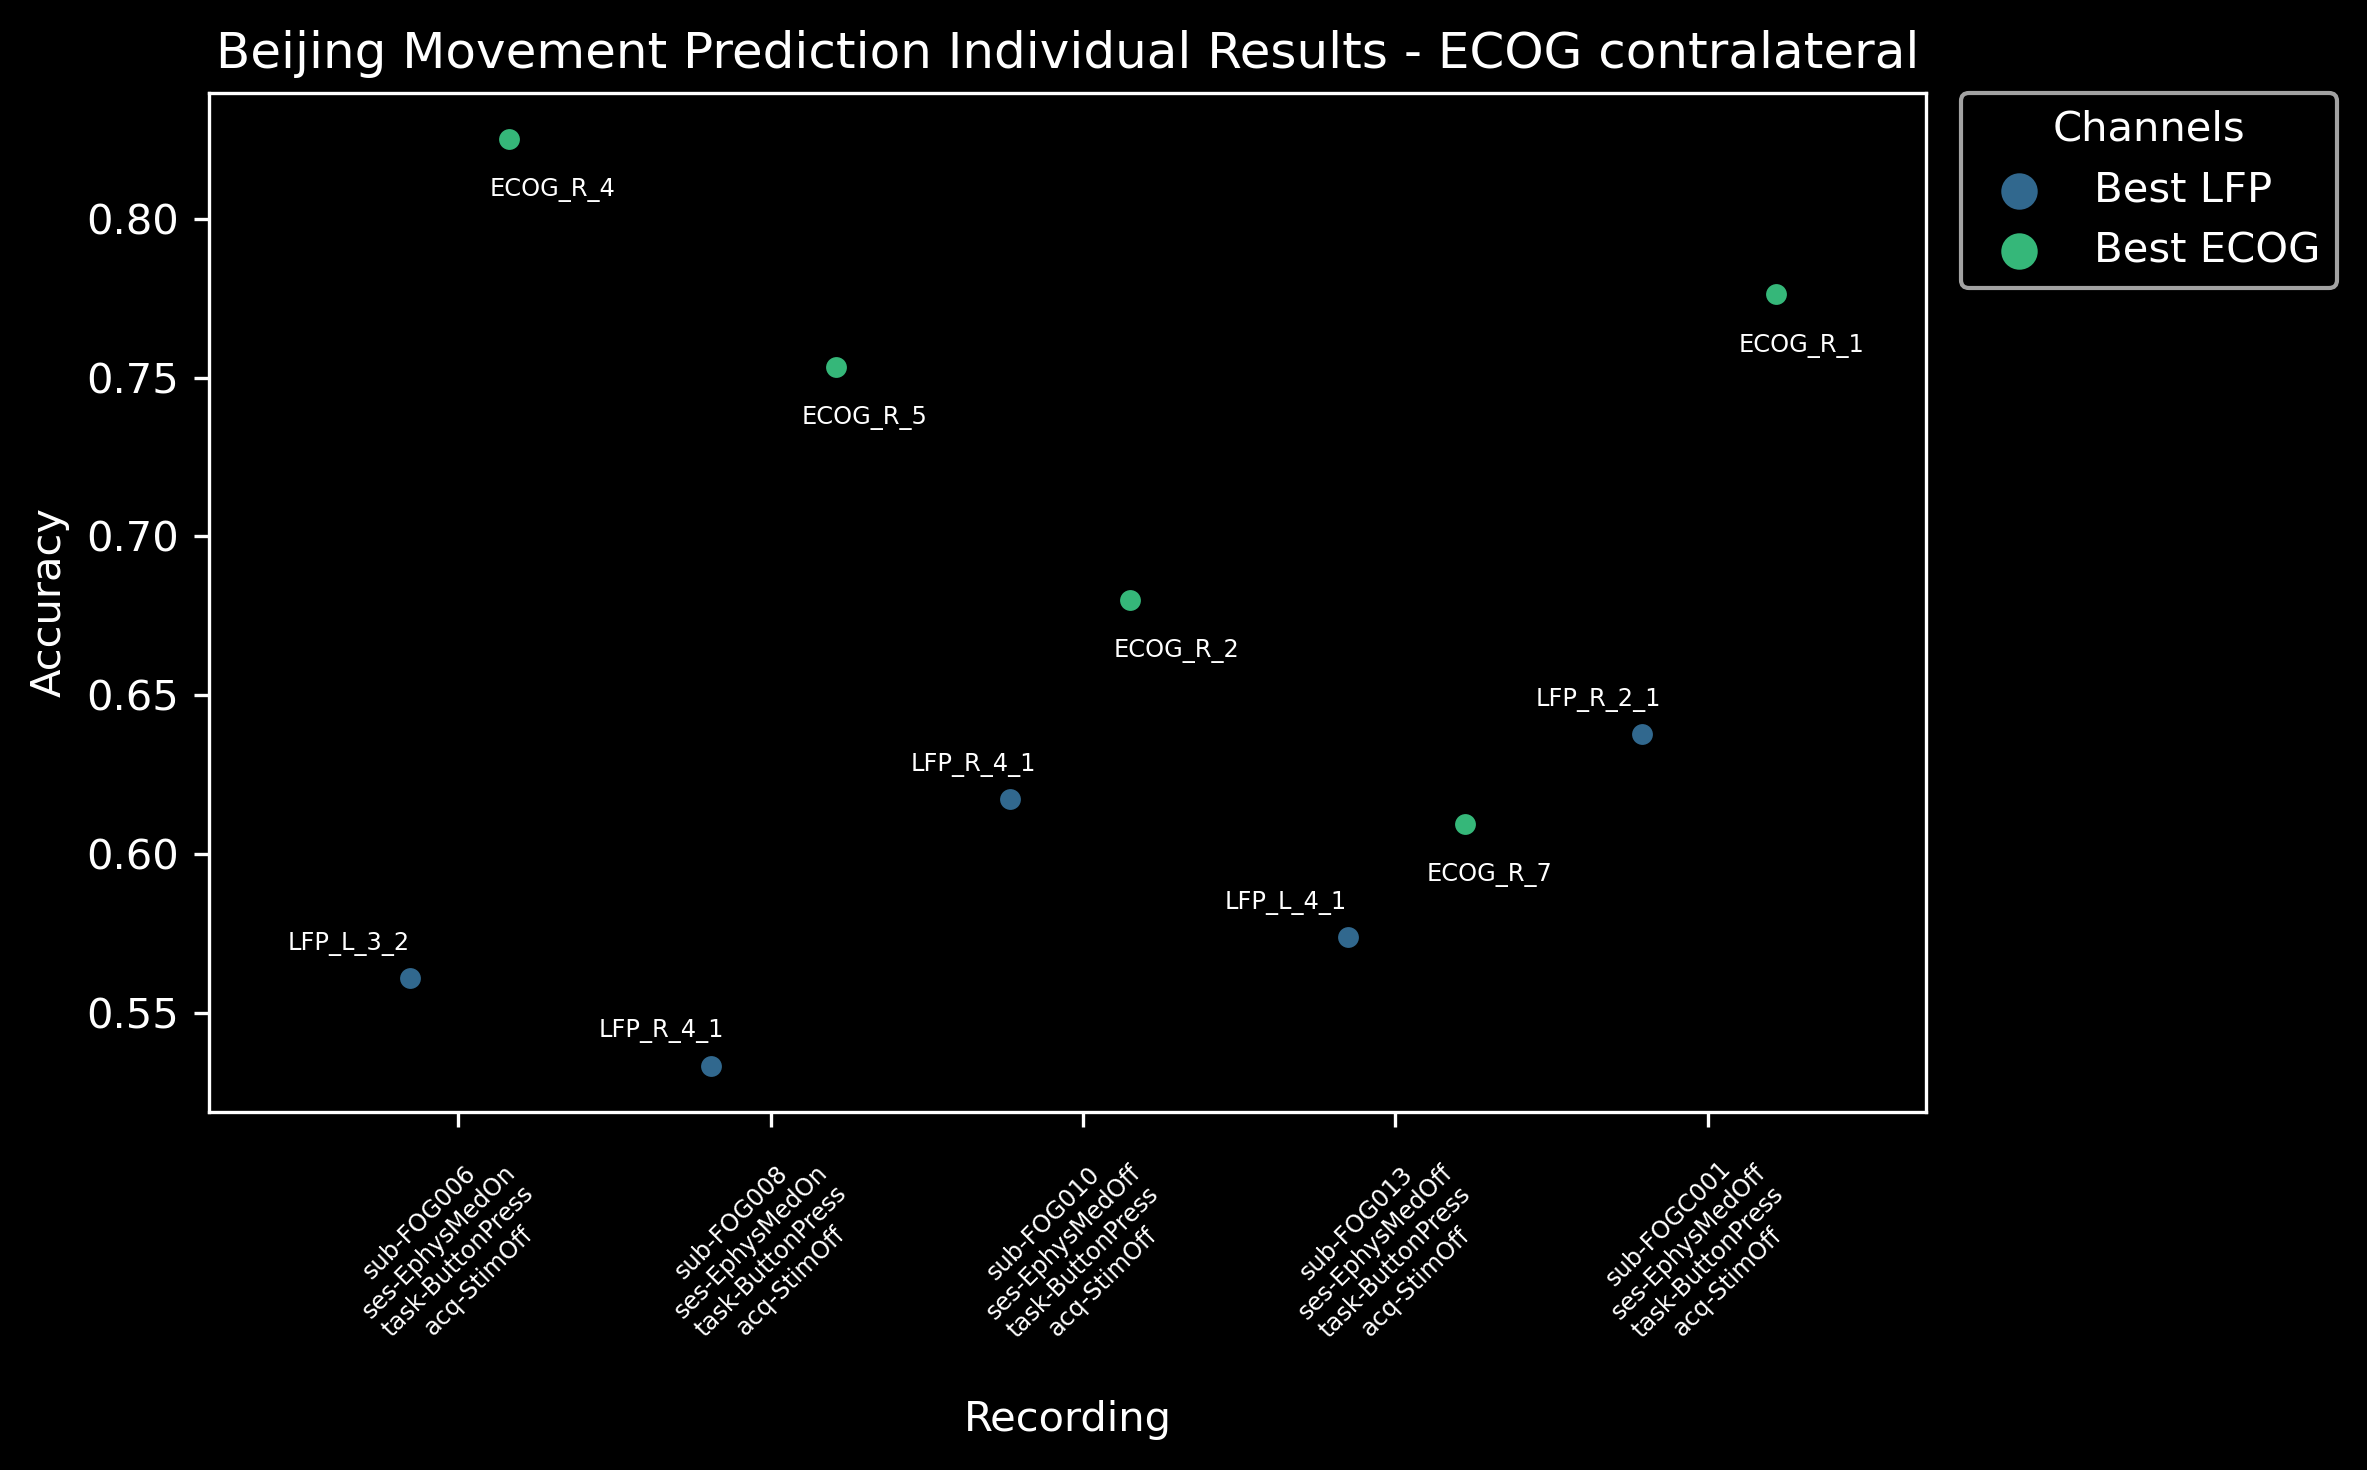

In [27]:
outpath = os.path.join(deriv_root, 'beijing_movement_class_sLDA_no_feat_clip_indiv_scores_contralat_dark.png')
df = final_df
plt.style.use('dark_background')
alpha_box = 0.4
plt.figure(figsize=(8,5), dpi=300)

ax = sb.stripplot(x="Recording", y="Accuracy", hue="Channel", 
                  data=df, palette="viridis", dodge=True, s=5)
tick_label = ax.get_xticklabels()
tick_dict = dict()
for x in ax.get_xticks():
    tick_dict[tick_label[x].get_text()] = x
for line, name in enumerate(df.index):
    if "LFP" in df["Best_Channel"][line]:
        x_offset = -0.35
        y_offset = +0.009
        align = 'center'
    elif "ECOG" in df["Best_Channel"][line]:
        x_offset = +0.3
        y_offset = -0.018
        align = 'center'
    ax.text(tick_dict[name]+x_offset, df.Accuracy[line]+y_offset, 
             df.Best_Channel[line], horizontalalignment=align, 
             size='xx-small', color='white')

plt.xticks(rotation=45)
xlabels = [item.get_text() for item in ax.get_xticklabels()]
new_xlabels = [xtick.replace('_','\n')[:-11] for xtick in xlabels]
ax.set_xticklabels(new_xlabels, fontdict={'fontsize':'xx-small'})
ax.set_xlim(left=ax.get_xlim()[0]-0.3, right=ax.get_xlim()[1]+0.2)
#ax.set_ylim(bottom=ax.get_ylim()[0]-0.01)
handles, labels = ax.get_legend_handles_labels()
l = plt.legend(handles[:len(handles)], labels[:len(labels)], 
               bbox_to_anchor=(1.02, 1), loc=2, borderaxespad=0., title='Channels')
plt.title("Beijing Movement Prediction Individual Results - ECOG contralateral")
plt.tight_layout()
plt.savefig(outpath)

In [28]:
df_list = list()
for file in group_files[0:]:
    df = pd.read_csv(file, sep='\t', index_col=[0], header=[0])
    for col in df.columns:
        if "accuracy" in col:
            new_df = pd.DataFrame(columns = ['Accuracy', 'Channel', 'Hemisphere'], index=df.index)
            series = pd.Series(df[col], index=df.index)
            new_df['Accuracy'] = series
            new_df['Classification Target'] = "Movement" if "movement" in file else "Motor Onset"
            new_df['Channel'] = "Best LFP" if "LFP" in col else "Best ECOG"
            new_df['Hemisphere'] = "Contralateral" if "Contralateral" in file else "Ipsilateral"
            df_list.append(new_df)
final_df = pd.concat(df_list)

In [29]:
final_df

,Accuracy,Channel,Hemisphere,Classification Target
sub-FOG006_ses-EphysMedOn_task-ButtonPress_acq-StimOff_run-01_ieeg,0.559615,Best LFP,Contralateral,Motor Onset
sub-FOG008_ses-EphysMedOn_task-ButtonPress_acq-StimOff_run-01_ieeg,0.575833,Best LFP,Contralateral,Motor Onset
sub-FOG010_ses-EphysMedOff_task-ButtonPress_acq-StimOff_run-01_ieeg,0.617857,Best LFP,Contralateral,Motor Onset
sub-FOG013_ses-EphysMedOff_task-ButtonPress_acq-StimOff_run-01_ieeg,0.566250,Best LFP,Contralateral,Motor Onset
sub-FOGC001_ses-EphysMedOff_task-ButtonPress_acq-StimOff_run-01_ieeg,0.565385,Best LFP,Contralateral,Motor Onset
sub-FOG006_ses-EphysMedOn_task-ButtonPress_acq-StimOff_run-01_ieeg,0.770769,Best ECOG,Contralateral,Motor Onset
sub-FOG008_ses-EphysMedOn_task-ButtonPress_acq-StimOff_run-01_ieeg,0.541667,Best ECOG,Contralateral,Motor Onset
sub-FOG010_ses-EphysMedOff_task-ButtonPress_acq-StimOff_run-01_ieeg,0.642143,Best ECOG,Contralateral,Motor Onset
sub-FOG013_ses-EphysMedOff_task-ButtonPress_acq-StimOff_run-01_ieeg,0.628125,Best ECOG,Contralateral,Motor Onset
sub-FOGC001_ses-EphysMedOff_task-ButtonPress_acq-StimOff_run-01_ieeg,0.636154,Best ECOG,Contralateral,Motor Onset


In [30]:
final_df.columns

Index(['Accuracy', 'Channel', 'Hemisphere', 'Classification Target'], dtype='object')

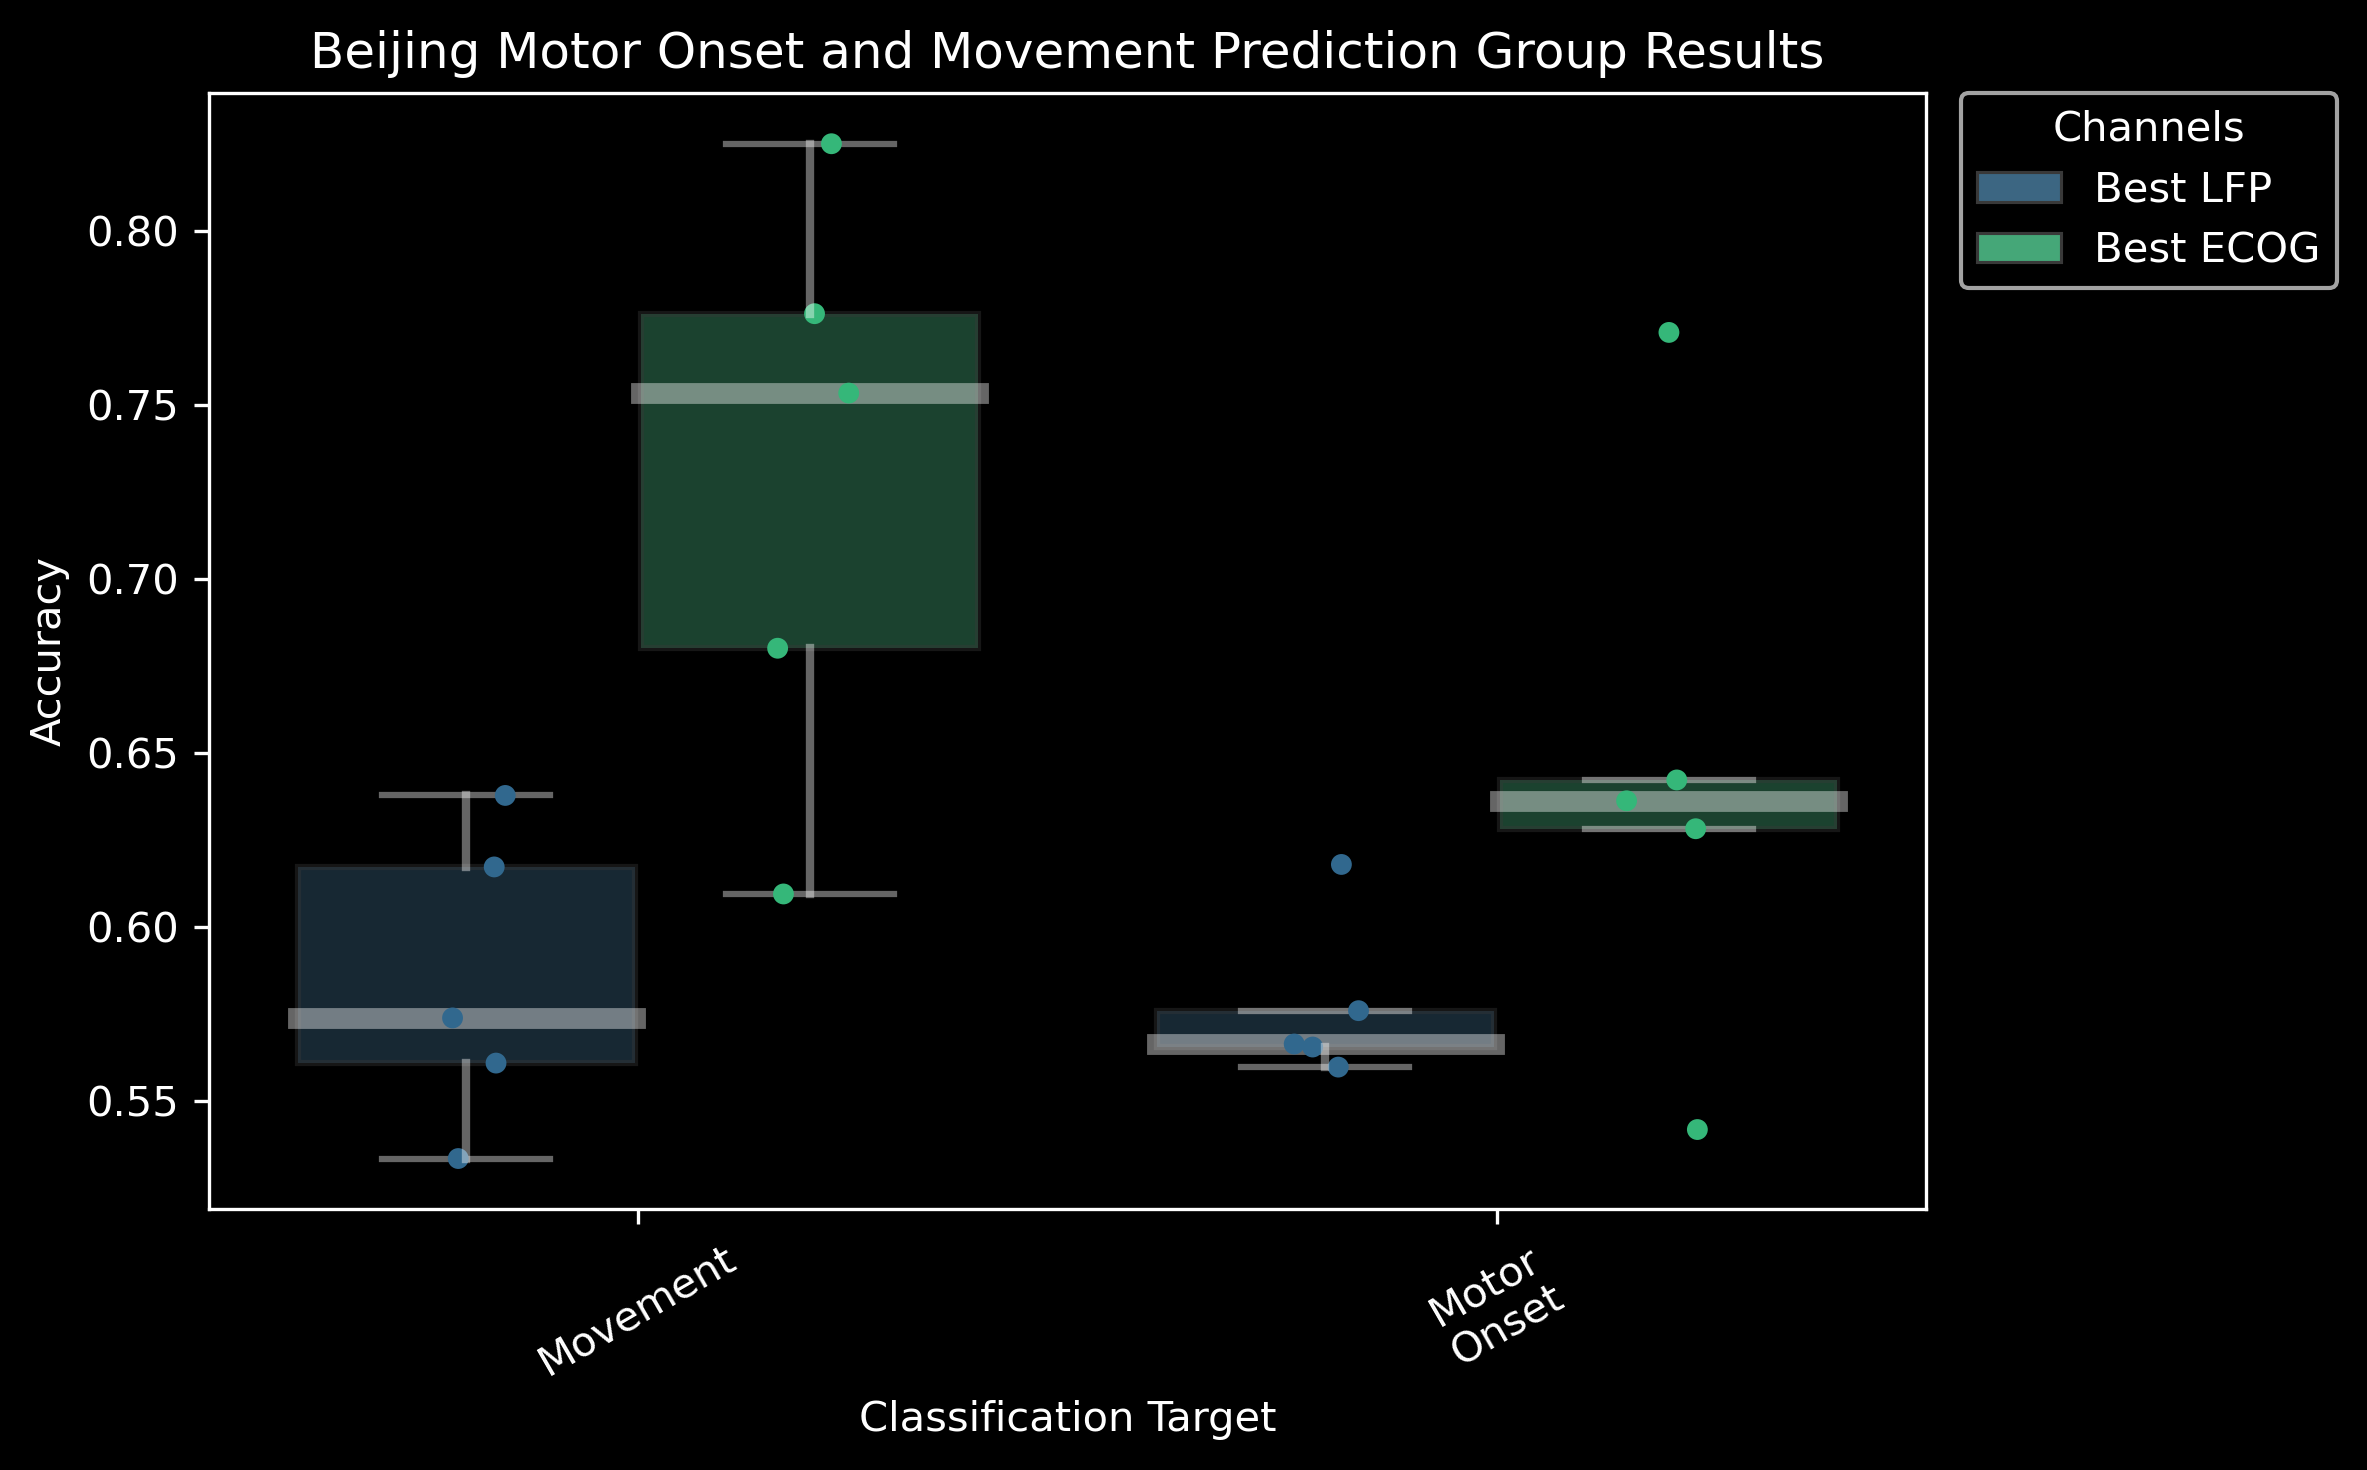

In [33]:
outpath = os.path.join(deriv_root, 'beijing_movement_mot_onset_class_sLDA_no_feat_clip_dark.png')
df = final_df
plt.style.use('dark_background')
alpha_box = 0.4
plt.figure(figsize=(8,5), dpi=300)
order = ['Movement', 'Motor Onset']
sb.boxplot(x="Classification Target", y="Accuracy", hue="Channel", order=order, 
           data=df, palette="viridis",
           showmeans=False, boxprops=dict(alpha=alpha_box), showcaps=True, showbox=True, 
           showfliers=False, notch=False,
           whiskerprops={'linewidth':2, "zorder":10, "alpha":alpha_box, "color":'white'},
           capprops={"alpha":alpha_box,"color":'white'},
           medianprops=dict(linestyle='-', linewidth=5, color="white", alpha=alpha_box))

ax = sb.stripplot(x="Classification Target", y="Accuracy", hue="Channel", order=order, 
             data=df,palette="viridis", dodge=True, s=5)

plt.xticks(rotation=30)
xlabels = [item.get_text() for item in ax.get_xticklabels()]
new_xlabels = [xtick.replace(' ','\n') for xtick in xlabels]
ax.set_xticklabels(new_xlabels) 
handles, labels = ax.get_legend_handles_labels()
l = plt.legend(handles[:len(handles)//2], labels[:len(labels)//2], bbox_to_anchor=(1.02, 1), loc=2, borderaxespad=0., title='Channels')
plt.title("Beijing Motor Onset and Movement Prediction Group Results")
plt.tight_layout()
plt.savefig(outpath)

In [87]:
df_list = list()
for file in group_files[1:]:
    df = pd.read_csv(file, sep='\t', index_col=[0], header=[0])
    for col in df.columns:
        if "accuracy" in col:
            new_df = pd.DataFrame(columns = ['Accuracy', 'Channel', 'Hemisphere'], index=df.index)
            series = pd.Series(df[col], index=df.index)
            new_df['Accuracy'] = series
            new_df['Channel'] = "Best LFP" if "LFP" in col else "Best ECOG"
            new_df['Hemisphere'] = "Contralateral" if "Contralateral" in file else "Ipsilateral"
            df_list.append(new_df)
final_df = pd.concat(df_list)

In [62]:
final_df.columns

Index(['Accuracy', 'Channel', 'Hemisphere'], dtype='object')

In [63]:
final_df

,Accuracy,Channel,Hemisphere
sub-FOG006_ses-EphysMedOn_task-ButtonPress_acq-StimOff_run-01_ieeg,0.568615,Best LFP,Contralateral
sub-FOG008_ses-EphysMedOn_task-ButtonPress_acq-StimOff_run-01_ieeg,0.542879,Best LFP,Contralateral
sub-FOG010_ses-EphysMedOff_task-ButtonPress_acq-StimOff_run-01_ieeg,0.571667,Best LFP,Contralateral
sub-FOG013_ses-EphysMedOff_task-ButtonPress_acq-StimOff_run-01_ieeg,0.566949,Best LFP,Contralateral
sub-FOGC001_ses-EphysMedOff_task-ButtonPress_acq-StimOff_run-01_ieeg,0.637308,Best LFP,Contralateral
sub-FOG006_ses-EphysMedOn_task-ButtonPress_acq-StimOff_run-01_ieeg,0.824308,Best ECOG,Contralateral
sub-FOG008_ses-EphysMedOn_task-ButtonPress_acq-StimOff_run-01_ieeg,0.728182,Best ECOG,Contralateral
sub-FOG010_ses-EphysMedOff_task-ButtonPress_acq-StimOff_run-01_ieeg,0.702222,Best ECOG,Contralateral
sub-FOG013_ses-EphysMedOff_task-ButtonPress_acq-StimOff_run-01_ieeg,0.608125,Best ECOG,Contralateral
sub-FOGC001_ses-EphysMedOff_task-ButtonPress_acq-StimOff_run-01_ieeg,0.737308,Best ECOG,Contralateral


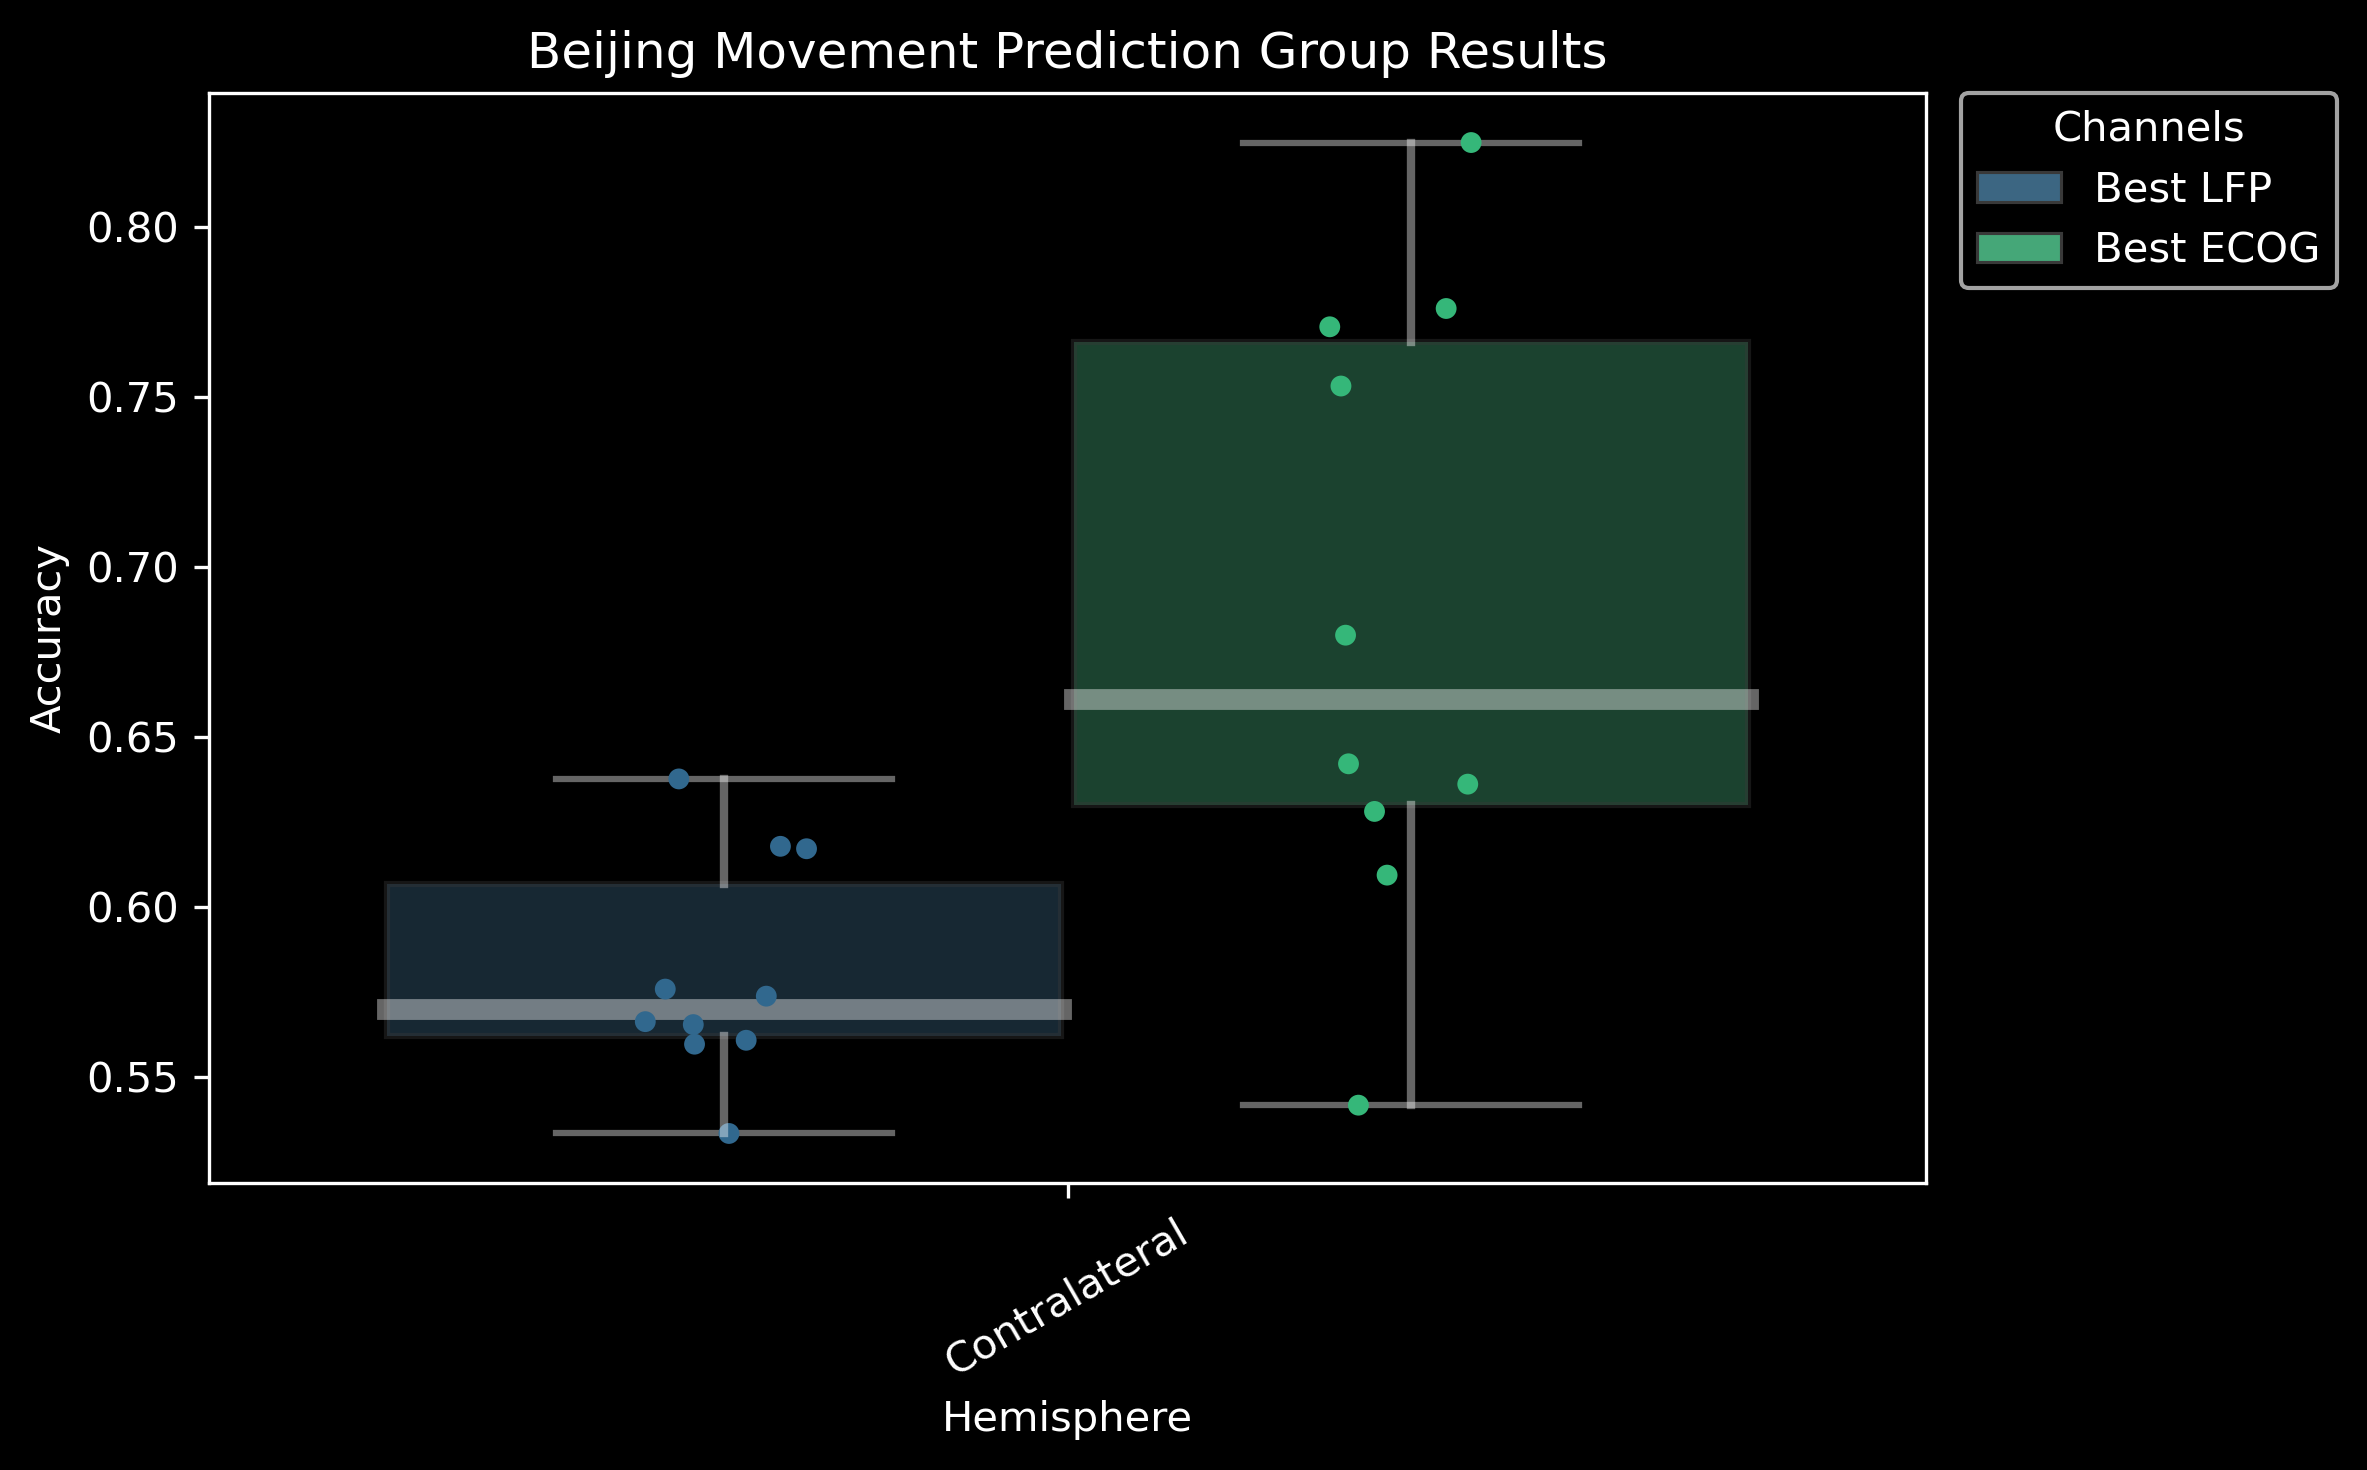

In [35]:
outpath = os.path.join(deriv_root, 'beijing_movement_class_sLDA_no_feat_clip_dark.png')
df = final_df
plt.style.use('dark_background')
alpha_box = 0.4
plt.figure(figsize=(8,5), dpi=300)
scores = ['Contralateral']
sb.boxplot(x="Hemisphere", y="Accuracy", hue="Channel", order=scores, 
           data=df, palette="viridis",
           showmeans=False, boxprops=dict(alpha=alpha_box), showcaps=True, showbox=True, 
           showfliers=False, notch=False,
           whiskerprops={'linewidth':2, "zorder":10, "alpha":alpha_box, "color":'white'},
           capprops={"alpha":alpha_box,"color":'white'},
           medianprops=dict(linestyle='-', linewidth=5, color="white", alpha=alpha_box))

ax = sb.stripplot(x="Hemisphere", y="Accuracy", hue="Channel", order=scores, 
                  data=df,palette="viridis", dodge=True, s=5)

plt.xticks(rotation=30)
xlabels = [item.get_text() for item in ax.get_xticklabels()]
new_xlabels = [xtick.replace(' ','\n') for xtick in xlabels]
ax.set_xticklabels(new_xlabels) 
handles, labels = ax.get_legend_handles_labels()
l = plt.legend(handles[:len(handles)//2], labels[:len(labels)//2], bbox_to_anchor=(1.02, 1), loc=2, borderaxespad=0., title='Channels')
plt.title("Beijing Movement Prediction Group Results")
plt.tight_layout()
plt.savefig(outpath)

In [75]:
offsets = [-0.7, -0.2, -0., -2.0, -0.5]

In [103]:
nm_reader = NM_reader.NM_Reader(deriv_root)
feature_file in feature_list[3]
settings = nm_reader.read_settings(feature_file)

# read run_analysis
run_analyzer = nm_reader.read_run_analyzer()

# optionally read ML estimations
ML_est = nm_reader.read_ML_estimations()

df_ = nm_reader.read_M1(feature_file)
features_ = nm_reader.read_features(feature_file)

label = 'EMG_squared'
channels = np.array(settings['ch_names'])
label_name = [ch for ch in channels if label in ch]
dat_label = nm_reader.read_label(label_name[0])

no _ML file computed


In [104]:
features_.columns

Index(['Unnamed: 0', 'ECOG_R_1_SM_HH-avgref_bandpass_activity_theta',
       'ECOG_R_1_SM_HH-avgref_bandpass_mobility_theta',
       'ECOG_R_1_SM_HH-avgref_bandpass_complexity_theta',
       'ECOG_R_1_SM_HH-avgref_bandpass_activity_alpha',
       'ECOG_R_1_SM_HH-avgref_bandpass_mobility_alpha',
       'ECOG_R_1_SM_HH-avgref_bandpass_complexity_alpha',
       'ECOG_R_1_SM_HH-avgref_bandpass_activity_low beta',
       'ECOG_R_1_SM_HH-avgref_bandpass_mobility_low beta',
       'ECOG_R_1_SM_HH-avgref_bandpass_complexity_low beta',
       ...
       'LFP_R_4_3_STN_PI_bandpass_mobility_all gamma',
       'LFP_R_4_3_STN_PI_bandpass_complexity_all gamma',
       'LFP_R_4_3_STN_PI_RawHjorth_Activity',
       'LFP_R_4_3_STN_PI_RawHjorth_Mobility',
       'LFP_R_4_3_STN_PI_RawHjorth_Complexity', 'LFP_R_4_3_STN_PI_raw', 'time',
       'EMG_L_RMS_500', 'EMG_squared', 'MISC_10_TTL'],
      dtype='object', length=453)

In [108]:
import emg

In [107]:
%matplotlib qt
plt.plot(dat_label)
plt.plot(features_['ECOG_R_4_SM_HH-avgref_bandpass_activity_low gamma'])

In [98]:
len(features_)

6374

In [100]:
%matplotlib qt
plt.plot(dat_label)

sub-FOG006_ses-EphysMedOn_task-ButtonPress_acq-StimOff_run-01_ieeg
no _ML file computed
Plotting feature covariance matrix.


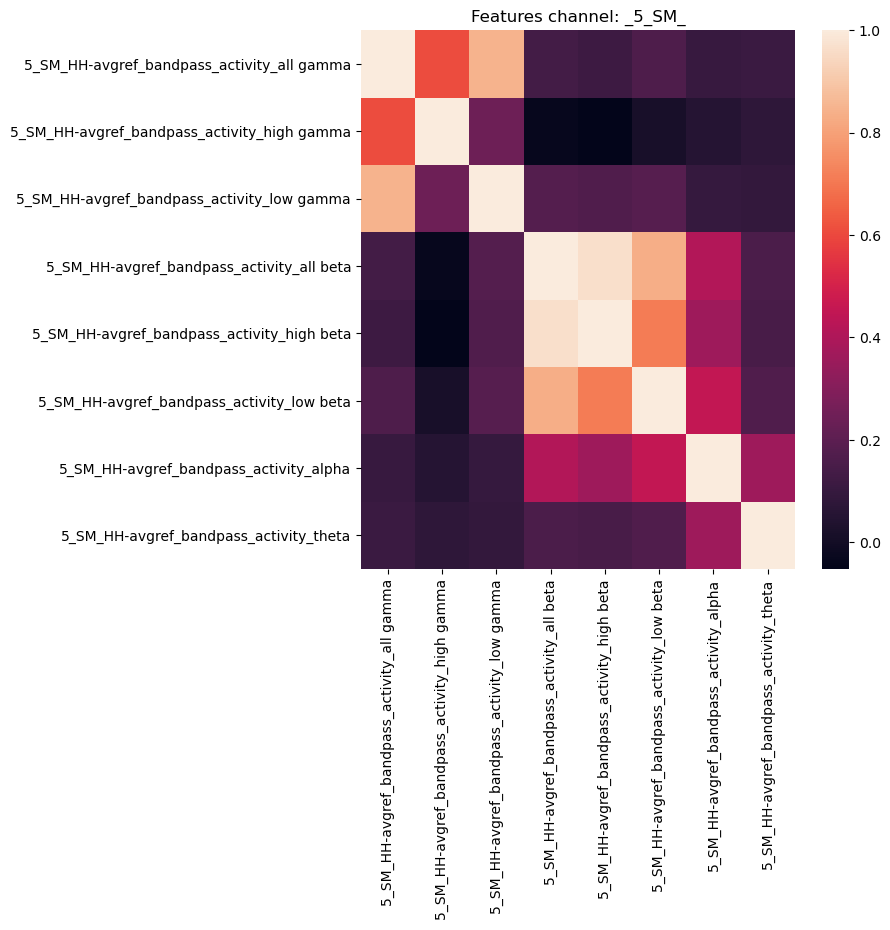

Correlation matrix figure saved to C:\Users\richa\OneDrive - Charité - Universitätsmedizin Berlin\Beijing_ECOG_LFP_derivatives\pipeline-MotOnsetPred_2021-04-26\derivatives\feat_no_clip\sub-FOG006_ses-EphysMedOn_task-ButtonPress_acq-StimOff_run-01_ieeg\Features_corr_matr_ch__5_SM__bandpass.png
Plotting feature target averaged.


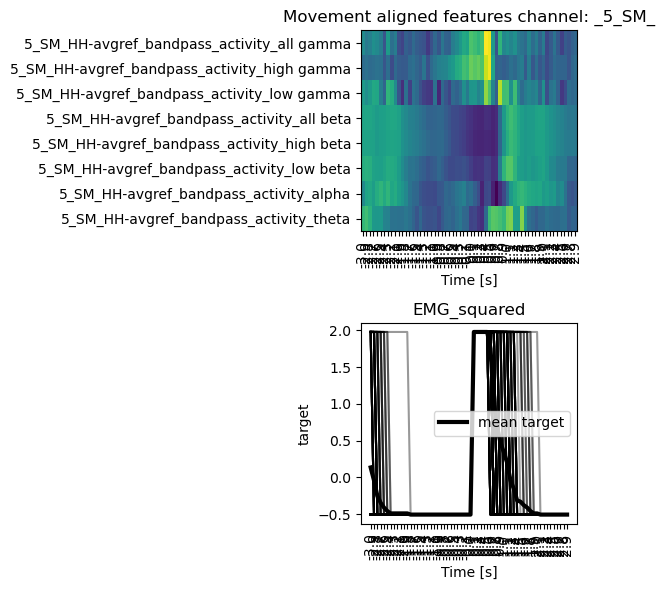

Feature epoch average figure saved to: C:\Users\richa\OneDrive - Charité - Universitätsmedizin Berlin\Beijing_ECOG_LFP_derivatives\pipeline-MotOnsetPred_2021-04-26\derivatives\feat_no_clip\sub-FOG006_ses-EphysMedOn_task-ButtonPress_acq-StimOff_run-01_ieeg\MOV_algined_features_ch__5_SM__bandpass.png
sub-FOG008_ses-EphysMedOn_task-ButtonPress_acq-StimOff_run-01_ieeg
no _ML file computed
Plotting feature covariance matrix.


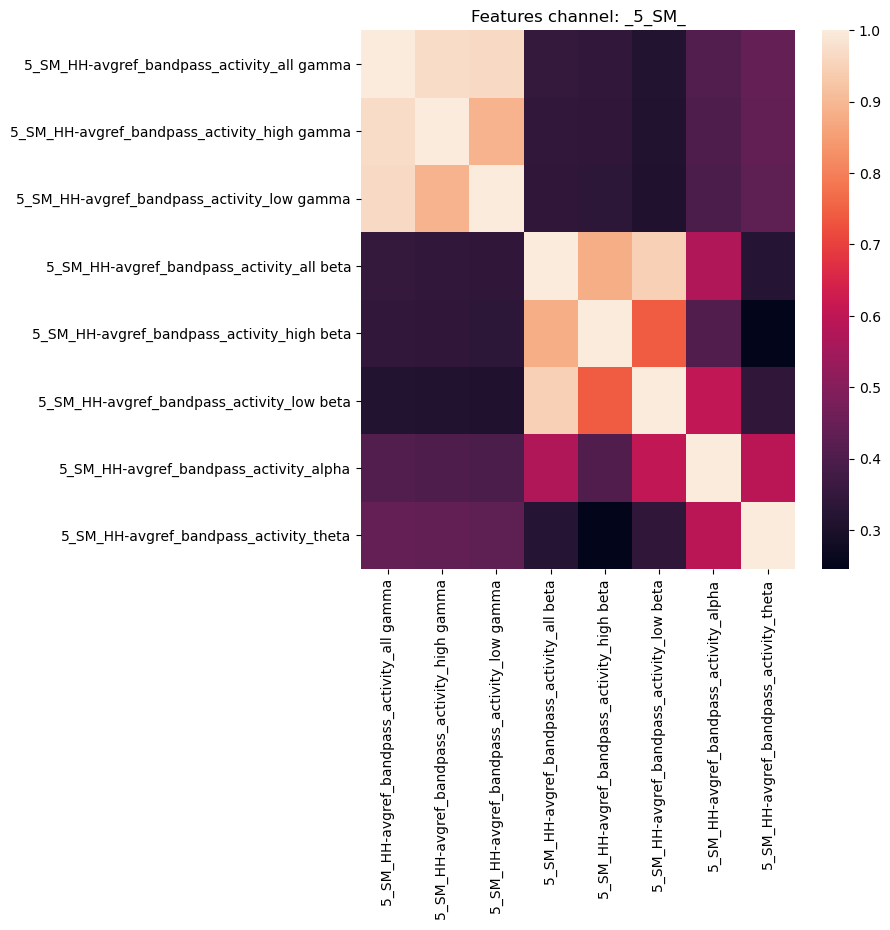

Correlation matrix figure saved to C:\Users\richa\OneDrive - Charité - Universitätsmedizin Berlin\Beijing_ECOG_LFP_derivatives\pipeline-MotOnsetPred_2021-04-26\derivatives\feat_no_clip\sub-FOG008_ses-EphysMedOn_task-ButtonPress_acq-StimOff_run-01_ieeg\Features_corr_matr_ch__5_SM__bandpass.png
Plotting feature target averaged.


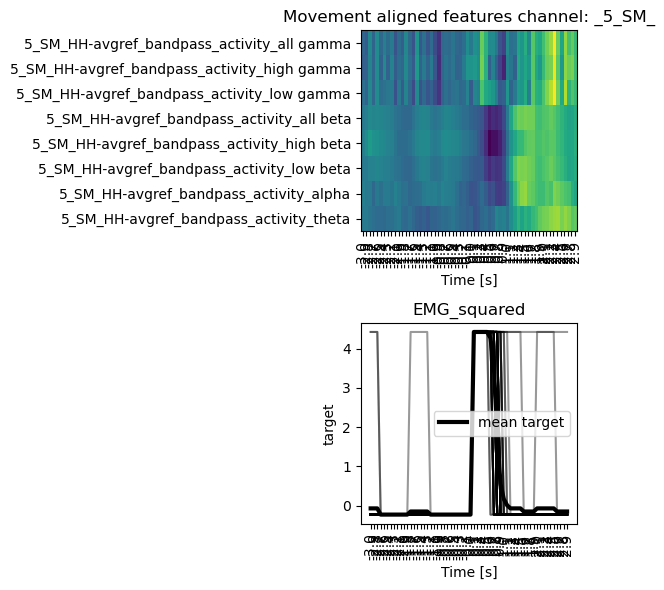

Feature epoch average figure saved to: C:\Users\richa\OneDrive - Charité - Universitätsmedizin Berlin\Beijing_ECOG_LFP_derivatives\pipeline-MotOnsetPred_2021-04-26\derivatives\feat_no_clip\sub-FOG008_ses-EphysMedOn_task-ButtonPress_acq-StimOff_run-01_ieeg\MOV_algined_features_ch__5_SM__bandpass.png
sub-FOG010_ses-EphysMedOff_task-ButtonPress_acq-StimOff_run-01_ieeg
no _ML file computed
Plotting feature covariance matrix.


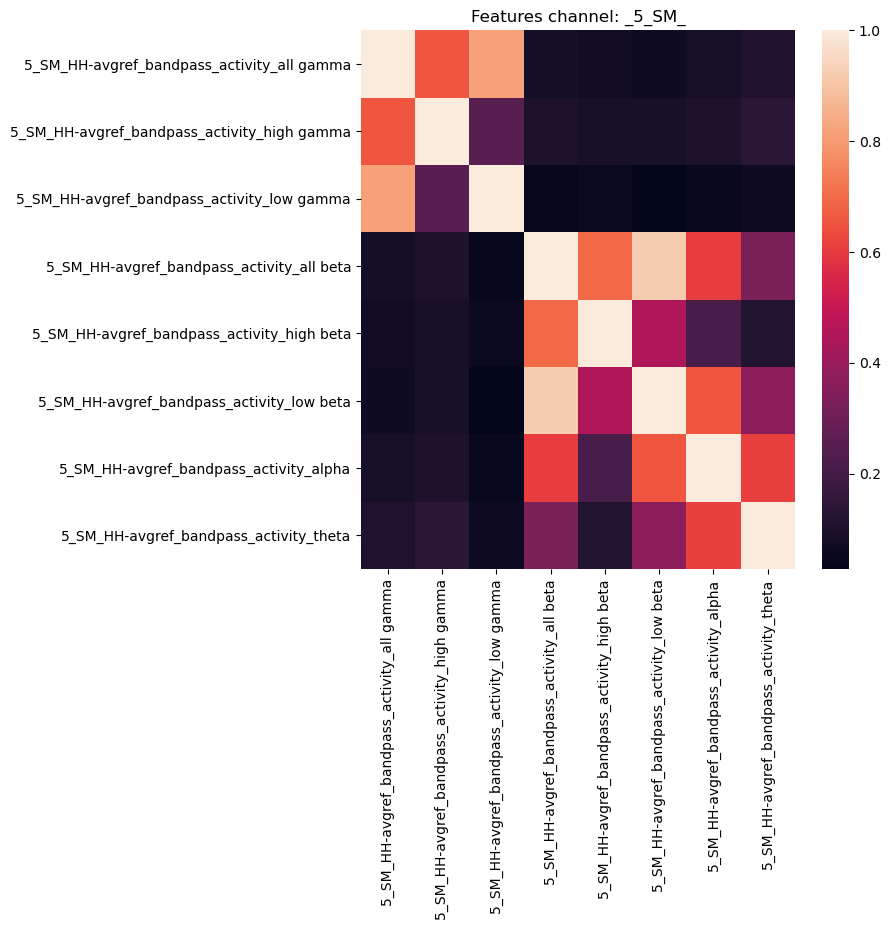

Correlation matrix figure saved to C:\Users\richa\OneDrive - Charité - Universitätsmedizin Berlin\Beijing_ECOG_LFP_derivatives\pipeline-MotOnsetPred_2021-04-26\derivatives\feat_no_clip\sub-FOG010_ses-EphysMedOff_task-ButtonPress_acq-StimOff_run-01_ieeg\Features_corr_matr_ch__5_SM__bandpass.png
Plotting feature target averaged.


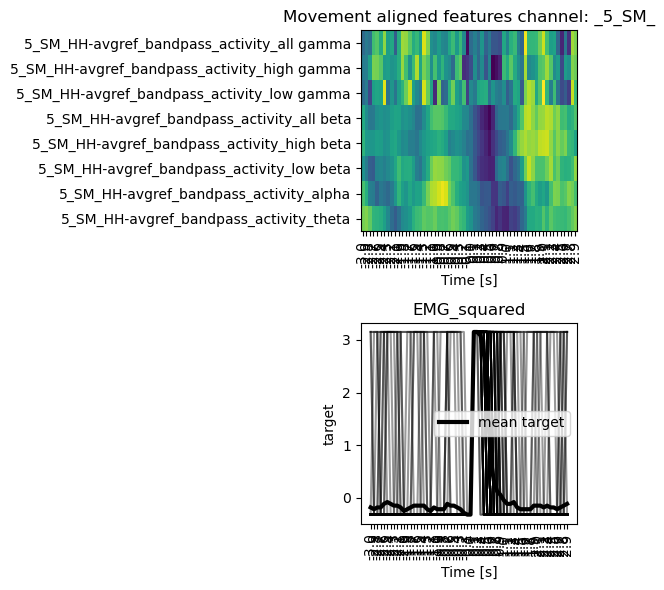

Feature epoch average figure saved to: C:\Users\richa\OneDrive - Charité - Universitätsmedizin Berlin\Beijing_ECOG_LFP_derivatives\pipeline-MotOnsetPred_2021-04-26\derivatives\feat_no_clip\sub-FOG010_ses-EphysMedOff_task-ButtonPress_acq-StimOff_run-01_ieeg\MOV_algined_features_ch__5_SM__bandpass.png
sub-FOG013_ses-EphysMedOff_task-ButtonPress_acq-StimOff_run-01_ieeg
no _ML file computed
Plotting feature covariance matrix.


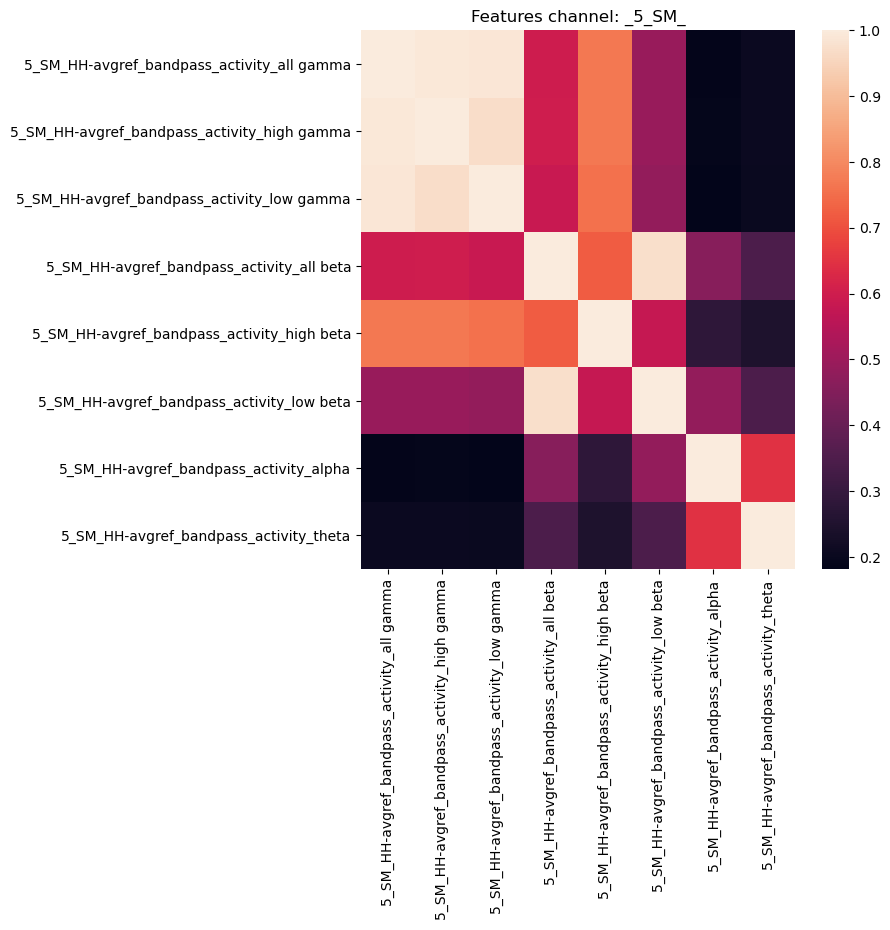

Correlation matrix figure saved to C:\Users\richa\OneDrive - Charité - Universitätsmedizin Berlin\Beijing_ECOG_LFP_derivatives\pipeline-MotOnsetPred_2021-04-26\derivatives\feat_no_clip\sub-FOG013_ses-EphysMedOff_task-ButtonPress_acq-StimOff_run-01_ieeg\Features_corr_matr_ch__5_SM__bandpass.png
Plotting feature target averaged.


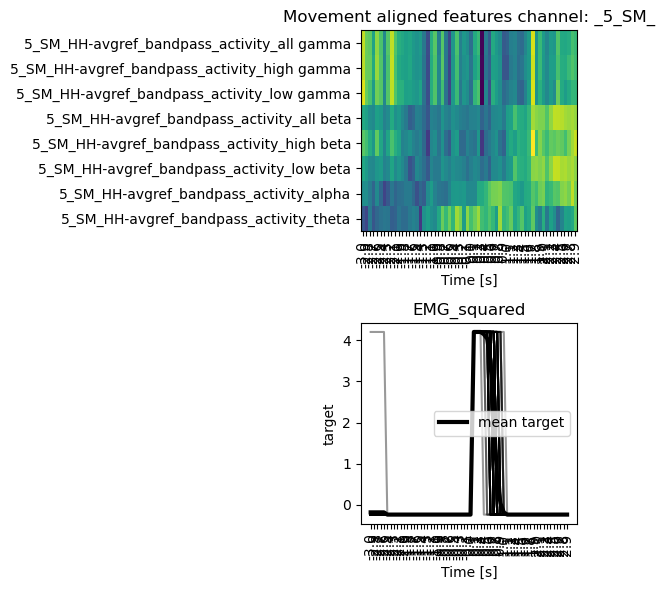

Feature epoch average figure saved to: C:\Users\richa\OneDrive - Charité - Universitätsmedizin Berlin\Beijing_ECOG_LFP_derivatives\pipeline-MotOnsetPred_2021-04-26\derivatives\feat_no_clip\sub-FOG013_ses-EphysMedOff_task-ButtonPress_acq-StimOff_run-01_ieeg\MOV_algined_features_ch__5_SM__bandpass.png
sub-FOGC001_ses-EphysMedOff_task-ButtonPress_acq-StimOff_run-01_ieeg
no _ML file computed
Plotting feature covariance matrix.


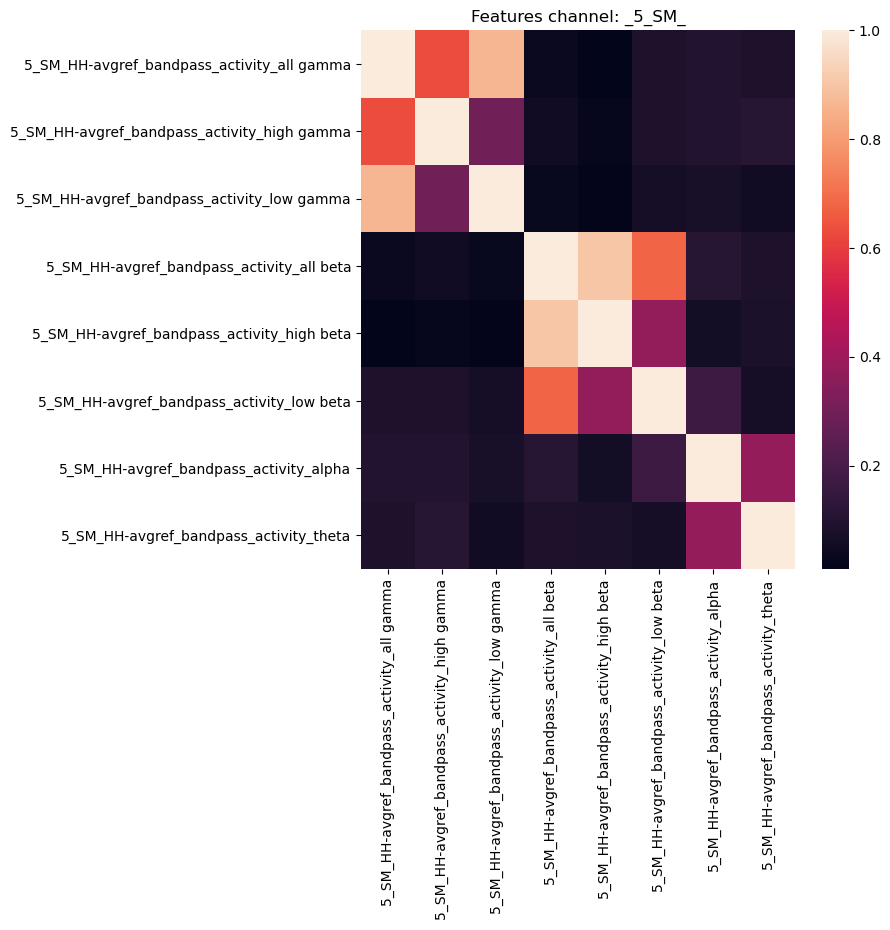

Correlation matrix figure saved to C:\Users\richa\OneDrive - Charité - Universitätsmedizin Berlin\Beijing_ECOG_LFP_derivatives\pipeline-MotOnsetPred_2021-04-26\derivatives\feat_no_clip\sub-FOGC001_ses-EphysMedOff_task-ButtonPress_acq-StimOff_run-01_ieeg\Features_corr_matr_ch__5_SM__bandpass.png
Plotting feature target averaged.


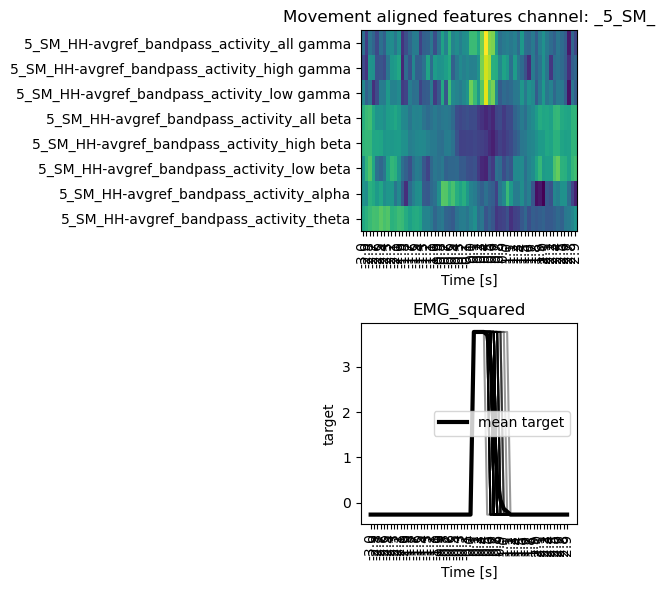

Feature epoch average figure saved to: C:\Users\richa\OneDrive - Charité - Universitätsmedizin Berlin\Beijing_ECOG_LFP_derivatives\pipeline-MotOnsetPred_2021-04-26\derivatives\feat_no_clip\sub-FOGC001_ses-EphysMedOff_task-ButtonPress_acq-StimOff_run-01_ieeg\MOV_algined_features_ch__5_SM__bandpass.png


In [41]:
from scipy import stats 

from importlib import reload

reload(NM_reader)

%matplotlib inline
plt.style.use('default')
nm_reader = NM_reader.NM_Reader(deriv_root)
feature_list = nm_reader.get_feature_list()
for feature_file in feature_list[:]:
    print(feature_file)
    run_example_read_features(feature_file, ch_name="_5_SM_", label='EMG_squared')